# Training the model on the basis of the data created.

In [1]:
# Import csv file from google drive
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/portfolio_system/dataS.csv')

Mounted at /content/drive


In [2]:
df.head()

,Unnamed: 0,age,risk,horizon,capital,equity,mf,cash,goal_preservation,goal_retirement,goal_short_term,goal_wealth
0,0,24,1,4,33868,60.61,34.34,5.05,False,False,False,False
1,1,26,2,8,18910,85.00,10.00,5.00,False,True,False,False
2,2,28,0,6,25194,61.22,28.57,10.20,False,False,False,True
3,3,25,0,7,22674,50.00,35.00,15.00,False,True,False,False
4,4,26,2,7,15662,69.00,21.00,10.00,False,False,True,False


In [3]:
# Train-Test split
from sklearn.model_selection import train_test_split

# Assigning required inputs and their outputs
X = df.drop(columns=['equity','mf','cash'])
y = df[['equity','mf','cash']]

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

We have imported the data, and also make train and test split. Now, we will go with model implementation.  

Firstly we will start with `RandomForestRegressor`, and then try to validate(evaluate) the results, and then move on with the other models and compare the performances.

In [4]:
# RandomForestRegressor implementation
from sklearn.ensemble import RandomForestRegressor

# n_jobs parameter controls the number of CPU cores used for processing the task
rf = RandomForestRegressor(n_estimators=300, max_depth=None, min_samples_split=5, random_state=42,n_jobs=-1)
rf.fit(X_train, y_train)

RandomForestRegressor(min_samples_split=5, n_estimators=300, n_jobs=-1,
                      random_state=42)

In [5]:
# Evaluation
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = rf.predict(X_test)
print("MAE: ", mean_absolute_error(y_test, y_pred))
print("R2: ", r2_score(y_test, y_pred))

MAE:  0.012963317624848647
R2:  0.9999326060680008


 **R2-Score** - It is also called coefficient of determination. It measures the proportion of variance in the dependent variable that can be explained by independent variable.  

1. R2 score close to 1 means that it can explain most part of the variance of dependent variable.
2. R2-score equals to 0 means that the model is predicting nothing but simply the mean.

In our metrics output, `MAE close to 0.01` means that predictions are good(mostly), and `R2_score close to 0.999` means that model is generalised well and explaining the most of the variance.  

Now, we will check the **feature importance** of the different features used as the input to the model.
1. After checking feature importance, as we thought, *risk* is the most important feature among all the other features.  

Now, When checked with random sample user, the model is consistent with the result, compared with actual allocation.





             feature  importance
2               risk    0.578059
8        goal_wealth    0.209623
6    goal_retirement    0.114555
1                age    0.038438
7    goal_short_term    0.028284
5  goal_preservation    0.023417
3            horizon    0.007610
4            capital    0.000008
0         Unnamed: 0    0.000007


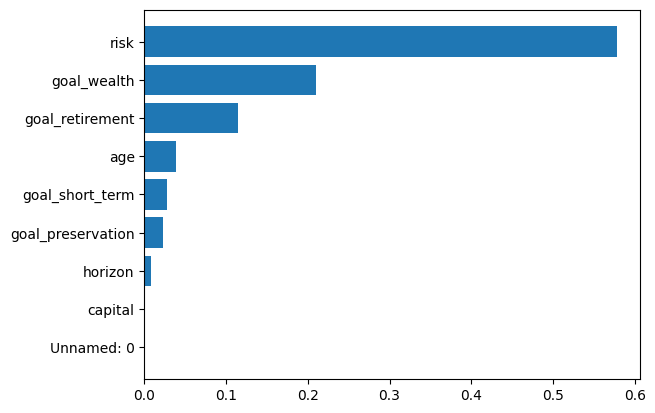

In [6]:
# Feature Importance
import matplotlib.pyplot as plt
importance = pd.DataFrame({"feature":X.columns, "importance":rf.feature_importances_}).sort_values(by="importance", ascending=False)
print(importance)

plt.barh(importance['feature'], importance['importance'])
plt.gca().invert_yaxis()
plt.show()

In [7]:
# Now, let's test the model with any random user
sample_user = X_test.iloc[[0]]
pred = rf.predict(sample_user)

print("Predicted Allocation: ", pred)
print("Actual Allocation: ", y_test.iloc[0].values)

Predicted Allocation:  [[61.86 27.84 10.31]]
Actual Allocation:  [61.86 27.84 10.31]


# Model Optimization ~ RandomForest

Now, after train the random forest model, we will try to optimise the model by tuning the hyperparameters and initially we will use *RandomSearchCV* that will randomly select the best parameters, and then probably, we will use *GridSearchCV* to find the best parameters in the best region. In random search, *Probability of finding good region increases faster in high-dimensional space.* as it is proven in the research paper.  


In [8]:
# Hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# Instance to the new random forest model that will randomly choose parameters
rf_ = RandomForestRegressor(random_state=42)

# Parameter Distribution
param_dist = {
    "n_estimators": [200,300,400,500],
    "max_depth": [None,10,20,30,40],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4],
    "max_features": ["sqrt", "log2", None]
}

random_search = RandomizedSearchCV(
    rf_,
    param_distributions=param_dist,
    n_iter=25,  #no. of random combinations
    cv=3,
    verbose=1,  #controls the amount of information printed during the model's training process
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


RandomizedSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30, 40],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [200, 300, 400, 500]},
                   random_state=42, verbose=1)

In [9]:
# Model's best parameters after tuning
print("Best parameters: ")
print(random_search.best_params_)
best_rf = random_search.best_estimator_

Best parameters: 
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': None}


In [10]:
# Evaluate the model with tuned parameters
y_pred_tuned = best_rf.predict(X_test)
print("Tuned R2:", r2_score(y_test,y_pred_tuned))
print("Tuned MAE:", mean_absolute_error(y_test, y_pred_tuned))

Tuned R2: 0.9999433744676348
Tuned MAE: 0.011692570000085202


In [11]:
# Check for the overfitting after tuning
print("Train R2:", r2_score(y_train, best_rf.predict(X_train)))
print("Test R2:", r2_score(y_test, y_pred_tuned))

Train R2: 0.9999935294858849
Test R2: 0.9999433744676348




After tuning the hyperparameters, we get the best parameters, and then evaluate the model on the basis of these parameters, on the metrics - R2_score, MAE. Then, we check for the overfitting of the train and test set.  
After checking overfitting, the r2_score for both train and test set is similar, that is, model is generalizing well.  

Now, we will compare our model with different stratagies implied on same dataset. We will compare random forest result with *gradient boosting* and *XgBoost*.  

Unlike randomforestregressor, `gradientboosting` does not support multiple output directly. Therefore, we have to wrap it up with `MultiOutputRegressor`.  

Neural Networks: optimize a fixed model by updating its parameters (weights)via gradient descent, which changes predictions directly.

 `Gradient Boosting`: performs stage-wise functional gradient descent.
 Instead of modifying existing tree parameters, it adds a new tree
 (i.e., a new basis function) at each iteration to approximate the
 negative gradient of the loss.  

 The model improves by expanding the function, not by adjusting previously learned structures.  


`XGBoost`: A highly optimized, regularized, second-order version of gradient boosting. XGboost behaves more like **newton's method in function space**.

In [12]:
# Gradient Boosting
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor

gbr = MultiOutputRegressor(
    GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    )
)

gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)

print("Gradient Boosting R2: ", r2_score(y_test, y_pred_gbr))
print("Gradient Boosting MAE: ", mean_absolute_error(y_test,y_pred_gbr))

Gradient Boosting R2:  0.9988462167062737
Gradient Boosting MAE:  0.30667983450469627


In [13]:
# xgBoost
from xgboost import XGBRegressor

xgb = MultiOutputRegressor(
    XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
)